# 7.3 质量因子：盈利能力、应计利润与 QV 策略

> **核心矛盾**：高 ROE 的公司往往已被市场充分定价。
> 质量因子的精妙在于捕捉「盈利质量高但市场尚未充分定价」的机会。

## 学习目标
- 理解质量因子的五个维度及其**经济学依据**
- 深入理解 Sloan 应计利润异象：**会计利润≠真实盈利**
- 构建并验证价值+质量（QV）复合因子
- 理解为什么 QV 优于单因子


## 第一部分：质量的五个维度——为什么每个都重要？

| 维度 | 指标 | 方向 | 为什么重要 |
|------|------|------|-----------|
| **盈利能力** | ROE | 越高越好 | 衡量股东资本的回报效率 |
| **盈利稳定性** | ROE 波动率 | **越低越好** | 稳定 ROE=持续护城河，波动大=靠运气 |
| **现金质量** | CFO / 净利润 | 越高越好 | >1 说明真实现金超过会计利润 |
| **财务安全** | 负债率 | **越低越好** | 低负债=危机时逆势扩张的能力 |
| **盈利质量** | 应计利润率 | **越负越好** | 负值=CFO>利润，利润真实可信 |

### 关键洞察：为什么 ROE 波动率很重要？

两家公司平均 ROE 都是 15%：
- 公司 A：每年稳定 15%  
- 公司 B：+30%, -5%, +25%, +10%, +5%（均值 15%，但忽上忽下）

**公司 A 更有价值**——稳定的 ROE 意味着真正的护城河（定价权、成本优势），
而不是靠周期性或运气暂时获利。这就是巴菲特寻找「持久竞争优势」的量化体现。


In [4]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

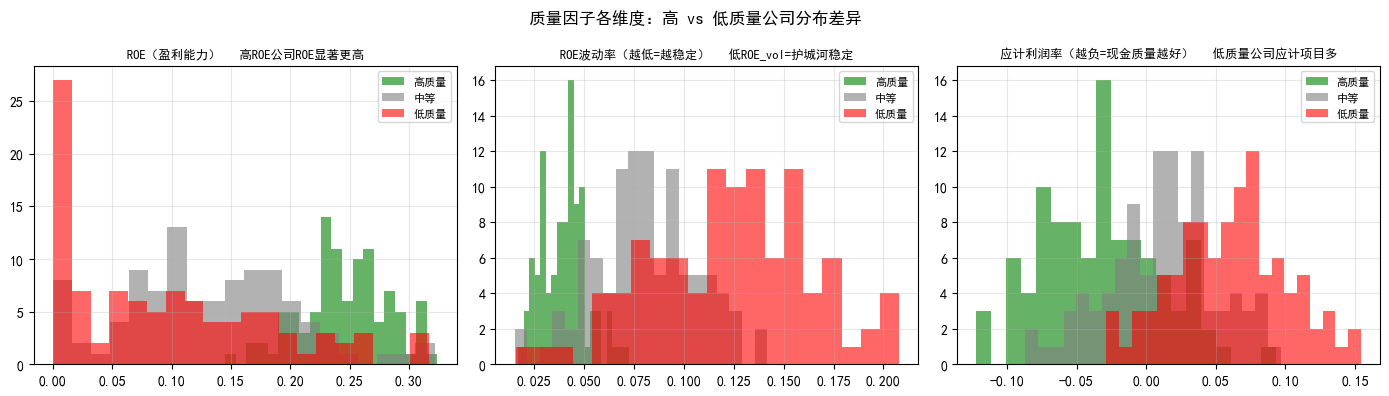

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import rankdata
np.random.seed(42)
n = 300

# 模拟三类公司：高质量、中等、低质量
def gen(n, roe_mu, roe_std, cf_mu, lev_mu, acc_mu):
    return pd.DataFrame({
        'ROE':     np.random.normal(roe_mu, roe_std, n).clip(0),
        'ROE_vol': np.abs(np.random.normal(roe_std, roe_std*0.3, n).clip(0.01)),
        'CF_ratio': np.random.normal(cf_mu, 0.2, n).clip(0.2, 2.5),
        'leverage': np.random.normal(lev_mu, 0.1, n).clip(0.1, 0.9),
        'accruals': np.random.normal(acc_mu, 0.04, n),
    })

high = gen(100, 0.25, 0.04, 1.3, 0.25, -0.03)
high['label'] = '高质量'
mid  = gen(100, 0.14, 0.08, 0.95, 0.45, 0.01)
mid['label'] = '中等'
low  = gen(100, 0.06, 0.12, 0.6, 0.68, +0.05)
low['label'] = '低质量'
df = pd.concat([high, mid, low], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label, note in zip(axes,
    ['ROE', 'ROE_vol', 'accruals'],
    ['ROE（盈利能力）', 'ROE波动率（越低=越稳定）', '应计利润率（越负=现金质量越好）'],
    ['高ROE公司ROE显著更高', '低ROE_vol=护城河稳定', '低质量公司应计项目多']):
    for lbl, color in [('高质量','green'), ('中等','gray'), ('低质量','red')]:
        df[df['label']==lbl][col].hist(bins=20, ax=ax, alpha=0.6, color=color, label=lbl)
    ax.set_title(f'{label}   {note}', fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('质量因子各维度：高 vs 低质量公司分布差异', fontsize=12)
plt.tight_layout(); plt.show()


## 第二部分：Sloan 应计利润异象（1996）——最重要的盈利质量信号

### 应计利润的本质

$$\text{净利润} = \text{经营现金流（CFO）} + \underbrace{\text{应计项目（Accruals）}}_{\text{「借来」的利润}}$$

应计项目的典型来源：
- **应收账款增加**：卖了货但还没收到钱，记入利润但 CFO 没有体现
- **存货增加**：生产了产品但未卖出，按成本暂不记为费用

**为什么应计利润多是坏事？**

1. 应收账款可能变成坏账，未来需要冲销 → 利润下调
2. 存货跌价 → 需要计提减值损失
3. 管理层可能故意通过应计项目美化当期业绩

**Sloan 的实证**：高应计利润组未来 12 月 **系统性跑输** 低应计利润组约 10%（年化）。

市场没有充分定价应计项目的信息——这是可以被量化捕捉的机会！


应计利润率 Spearman IC = 0.2802  (p = 1.7930e-10)


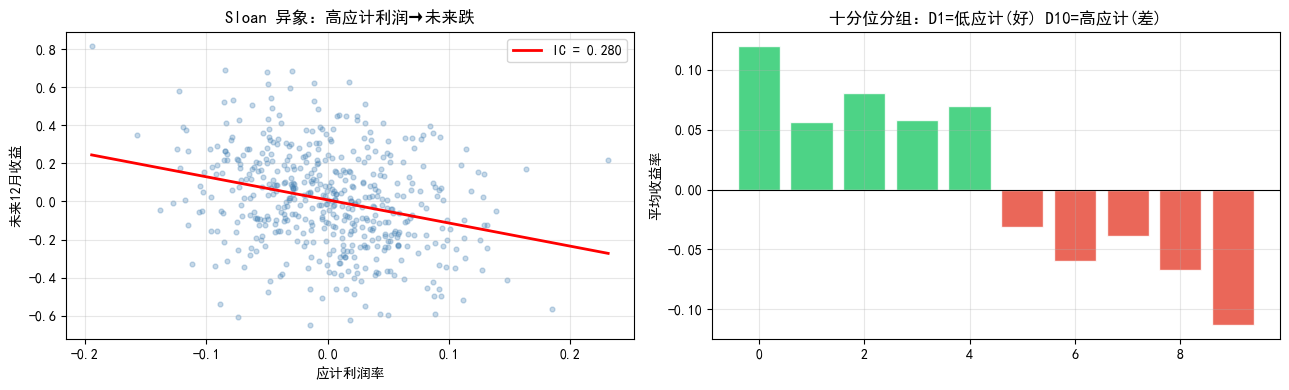

结论：低应计利润组(D1)系统性跑赢高应计利润组(D10)


In [6]:
# 验证 Sloan 应计利润异象
np.random.seed(42)
N = 500
accruals  = np.random.normal(0, 0.06, N)
noise     = np.random.normal(0, 0.25, N)
fwd_ret   = -0.9 * accruals + noise   # 高应计→未来跌

r, p = stats.spearmanr(accruals, fwd_ret)
print(f'应计利润率 Spearman IC = {-r:.4f}  (p = {p:.4e})')

deciles   = pd.qcut(accruals, 10, labels=[f'D{i+1}' for i in range(10)])
dec_ret   = pd.Series(fwd_ret).groupby(deciles).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(accruals, fwd_ret, alpha=0.3, s=12, color='steelblue')
m, b, *_ = stats.linregress(accruals, fwd_ret)
xr = np.linspace(accruals.min(), accruals.max(), 100)
axes[0].plot(xr, m*xr+b, 'r-', lw=2, label=f'IC = {-r:.3f}')
axes[0].set_xlabel('应计利润率'); axes[0].set_ylabel('未来12月收益')
axes[0].set_title('Sloan 异象：高应计利润→未来跌'); axes[0].legend(); axes[0].grid(alpha=0.3)

bar_c = ['#2ecc71' if x > 0 else '#e74c3c' for x in dec_ret]
axes[1].bar(range(10), dec_ret.values, color=bar_c, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('十分位分组：D1=低应计(好) D10=高应计(差)')
axes[1].set_ylabel('平均收益率'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('结论：低应计利润组(D1)系统性跑赢高应计利润组(D10)')


## 第三部分：QV 双因子——价值 + 质量优于单因子

### 为什么合并优于单独使用？

- **纯价值（低P/B）** → 选入困境股（价值陷阱），低质量
- **纯质量（高ROE）** → 选入高估值好公司，已被充分定价
- **QV 合成** → 优质但被低估的公司 = AQR 的 QARP 策略


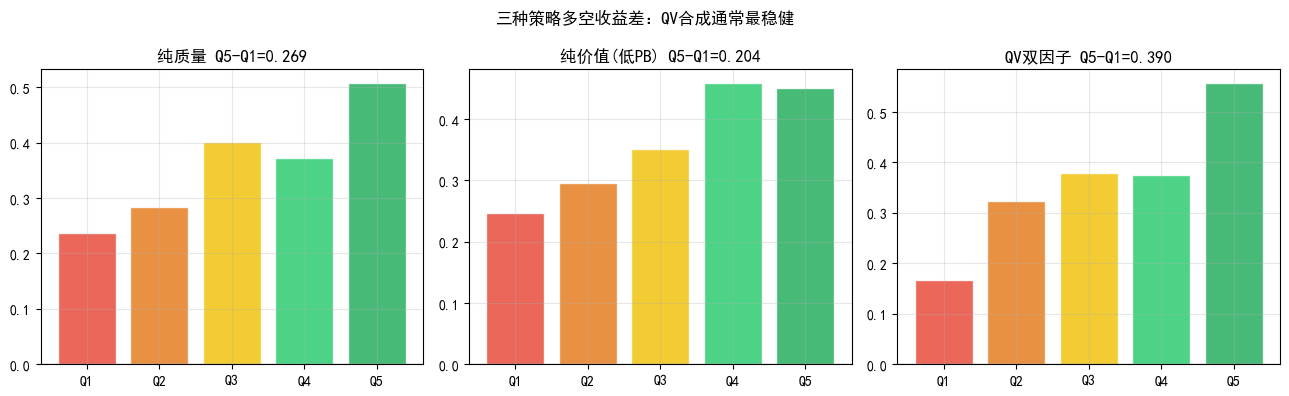

In [8]:
def rnk(s, hi=True):
    r = pd.Series(rankdata(s)) / len(s)
    return r if hi else 1 - r

# 构建五维质量分
df['q'] = (rnk(df['ROE']) + rnk(df['ROE_vol'],hi=False) +
            rnk(df['CF_ratio']) + rnk(df['leverage'],hi=False) +
            rnk(df['accruals'],hi=False)) / 5

# 价值因子
df['PB']    = np.random.lognormal(np.log(2),0.7,len(df)).clip(0.3,15)
df['value'] = rnk(df['PB'], hi=False)
df['QV']    = 0.5*df['q'] + 0.5*df['value']

# 前瞻收益
noise_q = np.random.normal(0, 0.25, len(df))
fwd = 0.4*df['q'] + 0.3*df['value'] + noise_q

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ['q','value','QV'], ['纯质量','纯价值(低PB)','QV双因子']):
    q5 = pd.qcut(df[col], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
    qr = fwd.groupby(q5).mean()
    sp = qr.iloc[-1] - qr.iloc[0]
    ax.bar(qr.index, qr.values,
           color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],alpha=0.85,edgecolor='w')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'{title} Q5-Q1={sp:.3f}'); ax.grid(alpha=0.3)
plt.suptitle('三种策略多空收益差：QV合成通常最稳健', fontsize=12)
plt.tight_layout(); plt.show()


## 🎯 练习

1. 对 A 股前 500 大市值股票计算五维质量分，统计高质量组（Q5）未来 6 个月平均超额收益。
2. AQR 的 QMJ 因子：做多高质量（Q5）、做空低质量（Q1），实现并计算年化 Sharpe，与沪深300对比。
3. 用 DuPont 分解验证：挑出 5 只 ROE>25% 的 A 股公司，拆解其 ROE 来源是利润率、周转率还是杠杆？

---
**下一节** → `04_earnings_surprise.ipynb`